# Computing the transition in the HANC model manually: general equilibrium, linear

In [1]:
import numpy as np
import numba as nb 
from consav.linear_interp import interp_1d_vec
import matplotlib.pyplot as plt
from consav.grids import equilogspace
from consav.markov import log_rouwenhorst

We continue from `03-Transition-Manually-GE-nonlinear.ipynb`, using the same HANC model with an annual calibration.

## Setup from the previous notebooks

The household block, the steady state and the partial equilibrium impulse response, as written in `02-Transition-Manually-PE.ipynb`.

In [2]:
class Parameters:
    def __init__(self):
        # preferences
        self.beta = 0.9498866874132476
        self.sigma = 1.0
        
        # production
        self.alpha = 1/3
        self.delta = 0.1/3
        self.Gamma = 1.0
        
        # grids
        self.Na = 500
        self.a_min = 0.0
        self.a_max = 10_000.0 
        self.a_grid = equilogspace(self.a_min,self.a_max,self.Na)

        # income
        self.rho_z = 0.95
        self.sigma_psi = 0.30*(1.0-self.rho_z**2.0)**0.5
        self.Nz = 7
        self.z_grid, self.z_trans,self.z_ergodic,_,_ = log_rouwenhorst(self.rho_z,self.sigma_psi,self.Nz)
        

par = Parameters()

In [3]:
""" 
Household backward step
"""

def egm_ss(r, w, par, max_iter = 50_000, tol = 1e-12, verbose = False):
    """ solve the EGM for the steady state """

    # a. initialize
    y = w*par.z_grid
    c = r*par.a_grid[np.newaxis,:] + y[:,np.newaxis] 
    Va = (1+r)*c**(-par.sigma)

    # b. iterate
    for it in range(max_iter):

        # i. solve backwards
        c, a, Va_new = solve_hh_backwards_one_step(par.z_trans, par.z_grid, par.a_grid, par.sigma, par.beta, r, w, Va)

        # ii. check convergence
        error = np.max(np.abs(Va - Va_new))
        if verbose:
            print(error)
        if error < tol:
            return c, a, Va_new

        Va = Va_new
    
    

def solve_hh_backwards_one_step(z_trans, z_grid, a_grid, sigma, beta, r, w, vbeg_a):

    # vbeg_a is the derivative of the value function at the beginning of the period
    Nz, Na = vbeg_a.shape
    a = np.zeros((Nz, Na))
    c = np.zeros((Nz, Na)) 
    
    # a. solve step
    for i_z in range(Nz):
    
        ## i. get c(a',z)
        c_endo = (beta*vbeg_a[i_z])**(-1/sigma)
        
        # ii. compute m_endo = c(a',z) + a'
        m_endo = c_endo + a_grid # current consumption + end-of-period assets
        
        # iii. interpolation to fixed grid
        m = (1+r)*a_grid + w*z_grid[i_z] # exogenous grid of coh
        interp_1d_vec(m_endo,a_grid,m,a[i_z]) # fill up the array a[i_z]
        a[i_z,:] = np.fmax(a[i_z,:],0.0) # enforce borrowing constraint
        c[i_z] = m-a[i_z]

    # b. expectation step
    RHS = (1+r)*c**(-sigma)
    vbeg_a_new = z_trans @ RHS

    return c, a, vbeg_a_new


In [4]:
""" 
Household forward step
"""

def get_lottery(a, a_grid):
    # step 1: find the i such that a' lies between gridpoints a_i and a_(i+1)
    a_i = np.searchsorted(a_grid, a, side='right') - 1
    a_i = np.clip(a_i, 0, len(a_grid)-2)

    # step 2: implement (8) to obtain lottery probabilities pi
    a_pi = (a_grid[a_i+1] - a)/(a_grid[a_i+1] - a_grid[a_i])
    
    return a_i, a_pi

@nb.njit
def forward_policy(D, a_i, a_pi):
    Dend = np.zeros_like(D)
    for e in range(a_i.shape[0]):
        for a in range(a_i.shape[1]):
            # send pi(e,a) of the mass to gridpoint i(e,a)
            Dend[e, a_i[e,a]] += a_pi[e,a]*D[e,a]
            
            # send 1-pi(e,a) of the mass to gridpoint i(e,a)+1
            Dend[e, a_i[e,a]+1] += (1-a_pi[e,a])*D[e,a]
            
    return Dend

@nb.njit
def forward_iteration(D, z_trans, a_i, a_pi):
    Dend = forward_policy(D, a_i, a_pi)    
    return z_trans.T @ Dend

def distribution_ss(a, par, tol=1E-10):
    a_i, a_pi = get_lottery(a, par.a_grid)

    # as initial D, use stationary distribution for s, plus uniform over a
    D = par.z_ergodic[:, np.newaxis] * np.ones_like(par.a_grid) / len(par.a_grid)

    # now iterate until convergence to acceptable threshold
    for _ in range(100_000):
        D_new = forward_iteration(D, par.z_trans, a_i, a_pi)
        if np.max(np.abs(D_new - D)) < tol:
            return D_new
        D = D_new



In [5]:
""" 
Household block steady-state
"""

def household_ss(r, w, par, max_iter = 10_000, tol = 1e-8, verbose = False):
    c, a, Va = egm_ss(r, w, par, max_iter, tol, verbose) 
    D = distribution_ss(a, par)
    A = np.sum(D * a)
    C = np.sum(D * c) 
    return A, C, D, a, c, Va 

In [6]:
def find_ss_beta(beta, par):
    par.beta = beta
    r = 0.05
    w = 1-par.alpha
    K = 4 
    A, _, _, _, _, _  = household_ss(r, w, par) 
    print(A-K)
    return A-K

from scipy.optimize import brentq 
par.beta = brentq(find_ss_beta, 0.9, 0.952, args=(par,))

r_ss = 0.05 
Y_ss = 1 
K_ss = 4 
par.alpha = 1/3 
par.Gamma = Y_ss /(K_ss**par.alpha)
par.delta = par.alpha * par.Gamma * K_ss**(par.alpha-1) - r_ss
w_ss = (1-par.alpha) * Y_ss
A_ss, C_ss, D_init, a_ss, c_ss, Va_term = household_ss(r_ss, w_ss, par) 

-3.9999999999999987


18.85097130114365
-3.9999999999999964
-3.9754237154914476
-3.6903026999917037
-2.764996557364749
-0.8924888421929031
1.3487170555343209


-0.2148552940458055
0.009983083845268581
-0.00043326116878583676
-8.180241124478016e-07


2.2041035663278308e-11
-1.8816908031737967e-09


In [7]:
@nb.njit
def forward_iteration_trans(D_init, z_trans, a_i, a_pi, T):
    Nz, Na = D_init.shape
    D = np.zeros((T, Nz, Na))
    D[0] = D_init
    for t in range(T-1):
        D[t+1] = forward_iteration(D[t], z_trans, a_i[t], a_pi[t])
    return D

In [8]:
def get_impulse_response(Va_term, D_init, r_vec, w_vec, par):
    T = r_vec.size

    # backward step
    a_trans = np.zeros((T, par.Nz, par.Na))
    c_trans = np.zeros((T, par.Nz, par.Na))
    Va_trans = Va_term.copy()
    for t in reversed(range(T)):
        c_trans[t], a_trans[t], Va_trans = solve_hh_backwards_one_step(par.z_trans, 
                                                                       par.z_grid, 
                                                                       par.a_grid, 
                                                                       par.sigma, 
                                                                       par.beta, 
                                                                       r_vec[t], 
                                                                       w_vec[t], 
                                                                       Va_trans)

    # forward step
    a_i, a_pi = get_lottery(a_trans, par.a_grid)

    D_trans = forward_iteration_trans(D_init, par.z_trans, a_i, a_pi, T)    
    A_trans = np.sum(D_trans * a_trans, axis = (1,2))
    C_trans = np.sum(D_trans * c_trans, axis = (1,2))

    return C_trans, A_trans, D_trans, c_trans, a_trans

The firm block, as written in `03-Transition-Manually-GE-nonlinear.ipynb`.

In [9]:
def firm(K, Gamma, K_init, par): 
    K_vec = K.copy()
    K_vec[1:] = K[:-1]
    K_vec[0] = K_init # K_vec is a vector of K_{t-1}

    Y = Gamma * K_vec**par.alpha # Y_t uses K_{t-1}
    I = K - (1-par.delta) * K_vec
    r = par.alpha * Y/K_vec - par.delta # r is the interest you receive at t
    w = (1-par.alpha) * Y # w is the wage you receive at t 
    return r, w, Y, I

The Jacobians of the firm block and, by brute force, of the household block, as computed in `03-Transition-Manually-GE-nonlinear.ipynb`.

In [10]:
T = 300

In [11]:
dw_dK_analytical = (1-par.alpha) * par.alpha * par.Gamma * K_ss**(par.alpha-1)
dr_dK_analytical = par.alpha * par.Gamma * (par.alpha-1) * K_ss**(par.alpha-2)

dw_dK = np.zeros((T, T))
dr_dK = np.zeros((T, T))

dw_dK[1:,:-1] = np.eye(T-1) * dw_dK_analytical
dr_dK[1:,:-1] = np.eye(T-1) * dr_dK_analytical

In [12]:
T = 300
r_vec = np.ones((T)) * r_ss
w_vec = np.ones((T)) * w_ss

_, A_no_shock, _, _, a_0 = get_impulse_response(Va_term, D_init, r_vec, w_vec, par)
a_ss = a_0[0] # to avoid numerical errors, run a blank transition and update steady state policy functions. This is for numerical precision only, not necessary per se.

In [13]:
h = 1e-4
J_w = np.zeros((T, T))

for s in range(T):
    r_vec = np.ones((T)) * r_ss
    w_vec = np.ones((T)) * w_ss
    
    w_vec[s] = w_ss + h

    C_trans, A_trans, _, _, _ = get_impulse_response(Va_term, D_init, r_vec, w_vec, par)
    J_w[:,s] = (A_trans - A_no_shock) / h

In [14]:
J_r = np.zeros((T, T))

for s in range(T):
    r_vec = np.ones((T)) * r_ss
    w_vec = np.ones((T)) * w_ss

    r_vec[s] = r_vec[s] + h

    C_trans, A_trans, _, _, _ = get_impulse_response(Va_term, D_init, r_vec, w_vec, par)
    J_r[:,s] = (A_trans - A_no_shock) / h

## Linear transitions

So far, we have computed MIT (perfect-foresight) shocks. At the steady-state, households believe there is no chance such a shock happens. Once the shock happens at $t=0$, they have perfect foresight over the path of $r$ and $w$, and believe no shock will happen again (strong assumption).

Another way is to linearize the model around the steady state. A first-order approximation of $H(\mathbf{K},\mathbf{\Gamma})=\mathbf{0}$ gives
$$
H_{\mathbf{K}}d\mathbf{K}+H_{\mathbf{\Gamma}}d\mathbf{\Gamma}=\mathbf{0}\Leftrightarrow d\mathbf{K}=-H_{\mathbf{K}}^{-1}H_{\mathbf{\Gamma}}d\mathbf{\Gamma}
$$
so once we have the Jacobians, the response to any shock path is a matrix product. We also need the Jacobians of $r$ and $w$ with respect to $\Gamma$ (`dr_dZ` and `dw_dZ` below).

In [15]:
dr_dZ_analytical = par.alpha * K_ss**(par.alpha-1)
dw_dZ_analytical = (1-par.alpha) * K_ss**par.alpha

dr_dZ = np.eye(T) * dr_dZ_analytical
dw_dZ = np.eye(T) * dw_dZ_analytical

In [16]:
T = 300
sigma = 0.02
rho = 0.9
dGamma = sigma * rho ** np.arange(T) 

H_K = J_w @ dw_dK + J_r @ dr_dK - np.eye(T)
H_Z = J_w @ dw_dZ + J_r @ dr_dZ  
G = -np.linalg.solve(H_K, H_Z) 
dK = G @ dGamma

In [17]:
K_trans = np.ones((T)) * K_ss
error = 1 
tol = 1e-8
adj = 0.1
while error > tol:
    r_trans, w_trans, Y_trans, I_trans = firm(K_trans, (par.Gamma +dGamma), K_ss, par)
    C_trans, A_trans, D_trans, c_trans, a_trans = get_impulse_response(Va_term, D_init, r_trans, w_trans, par)
    asset_market = A_trans - K_trans
    error = np.max(np.abs(asset_market))
    print(error)
    K_trans -= np.linalg.solve(H_K, asset_market)


0.2488828875265856
0.004111755898093428
3.9805062594489016e-05
1.207551001414231e-07


1.0458496291221309e-09


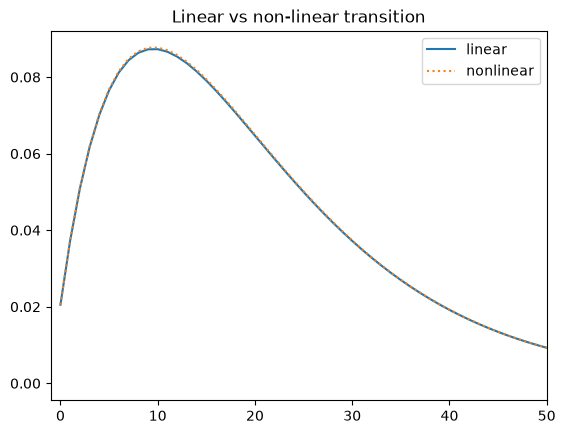

In [18]:
plt.plot(dK, label = 'linear')
plt.plot(K_trans - K_ss, label = 'nonlinear', linestyle = ':')
plt.xlim(-1, 50)
plt.legend()
plt.title('Linear vs non-linear transition')
plt.show()

It works! But what happens if we take a big shock?

2.933607006304852


0.3944145052461727
0.050385642855602875
0.0018915009466899946


0.00010062561880541665
8.000688178633197e-06


2.2200528349003434e-07
2.0131491140773505e-08
1.4061658504260777e-09


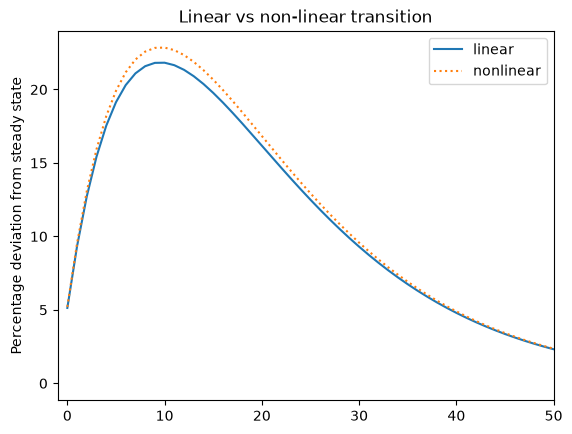

In [19]:
T = 300
sigma = 0.2
rho = 0.9
dGamma = sigma * rho ** np.arange(T) 

H_K = J_w @ dw_dK + J_r @ dr_dK - np.eye(T)
H_Z = J_w @ dw_dZ + J_r @ dr_dZ  
G = -np.linalg.solve(H_K, H_Z) 
dK = G @ dGamma

K_trans = np.ones((T)) * K_ss
error = 1 
tol = 1e-8
adj = 0.1
while error > tol:
    r_trans, w_trans, Y_trans, I_trans = firm(K_trans, (par.Gamma +dGamma), K_ss, par)
    C_trans, A_trans, D_trans, c_trans, a_trans = get_impulse_response(Va_term, D_init, r_trans, w_trans, par)
    asset_market = A_trans - K_trans
    error = np.max(np.abs(asset_market))
    print(error)
    K_trans -= np.linalg.solve(H_K, asset_market)

plt.plot(dK/K_ss * 100, label = 'linear')
plt.plot((K_trans - K_ss)/K_ss * 100, label = 'nonlinear', linestyle = ':')
plt.xlim(-1, 50)
plt.legend()
plt.ylabel('Percentage deviation from steady state')
plt.title('Linear vs non-linear transition')
plt.show()

The linear and non-linear paths now differ: with a large shock, the non-linearities of the model matter.

## Simulating the model 

We have seen that once we have obtained the Jacobian, we can compute IRFs really fast. How could we simulate the economy facing a sequence of shocks? 

First, assume that TFP innovations follow an AR-1 process:
$$
d\Gamma_t = \rho d\Gamma_{t-1} +\sigma \varepsilon_t
$$

In [20]:
rho = 0.9 
sigma = 0.01 
T = 300

dGamma = sigma * rho ** np.arange(T)
IRF_K = G @ dGamma  

simT = 2000
np.random.seed(2026)
epsilon = np.random.normal(0.0, 1.0, simT)

simT = epsilon.shape[0]
K_sim = np.zeros(simT)
for t in range(simT):
    K_sim[t] = 0.0
    for s in range(T):
        if t-s >= 0:
            K_sim[t] += IRF_K[s]*(epsilon[t-s])

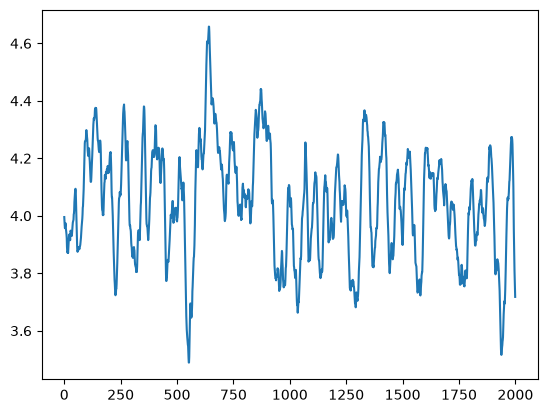

In [21]:
plt.plot(K_ss+K_sim)

In [22]:
Gamma_sim = np.zeros(simT) 

for t in range(simT):
    if t == 0:
        Gamma_sim[t] = sigma * epsilon[t]
    else:
        Gamma_sim[t] = rho * Gamma_sim[t-1] + sigma * epsilon[t]

Text(0, 0.5, 'dGamma')

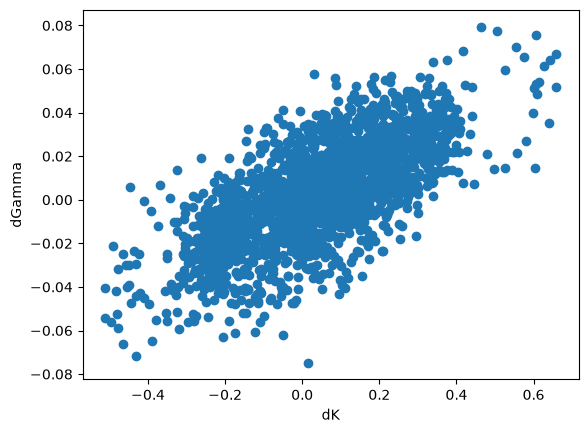

In [23]:
plt.scatter(K_sim, Gamma_sim)
plt.xlabel('dK')
plt.ylabel('dGamma')